In [1]:
!nvidia-smi

Thu Jan 29 00:04:44 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   65C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 39.6 MB/s eta 0:00:00


In [3]:
## connecting to the google drive

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
%cd /content/drive/MyDrive/00_GradProject/

/content/drive/MyDrive/00_GradProject


In [5]:
import ultralytics
ultralytics.checks()

Ultralytics 8.4.8 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 38.7/112.6 GB disk)


In [12]:
%cd /content/drive/MyDrive/00_GradProject/

!yolo task=detect mode=train model=yolov8l.pt data=data.yaml epochs=50 imgsz=224 plots=True
# !yolo task=detect mode=train model=yolov8l.pt data="/content/drive/MyDrive/ObjectdetectionData/custom.yaml" epochs=100 imgsz=640 batch=8 project="/content/drive/MyDrive/ObjectdetectionData/training_results" name=resultsfinalLarge


/content/drive/MyDrive/00_GradProject
Ultralytics 8.4.8 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8l.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=

In [9]:
!ls runs/detect/train3


ls: cannot access 'runs/detect/train3': No such file or directory


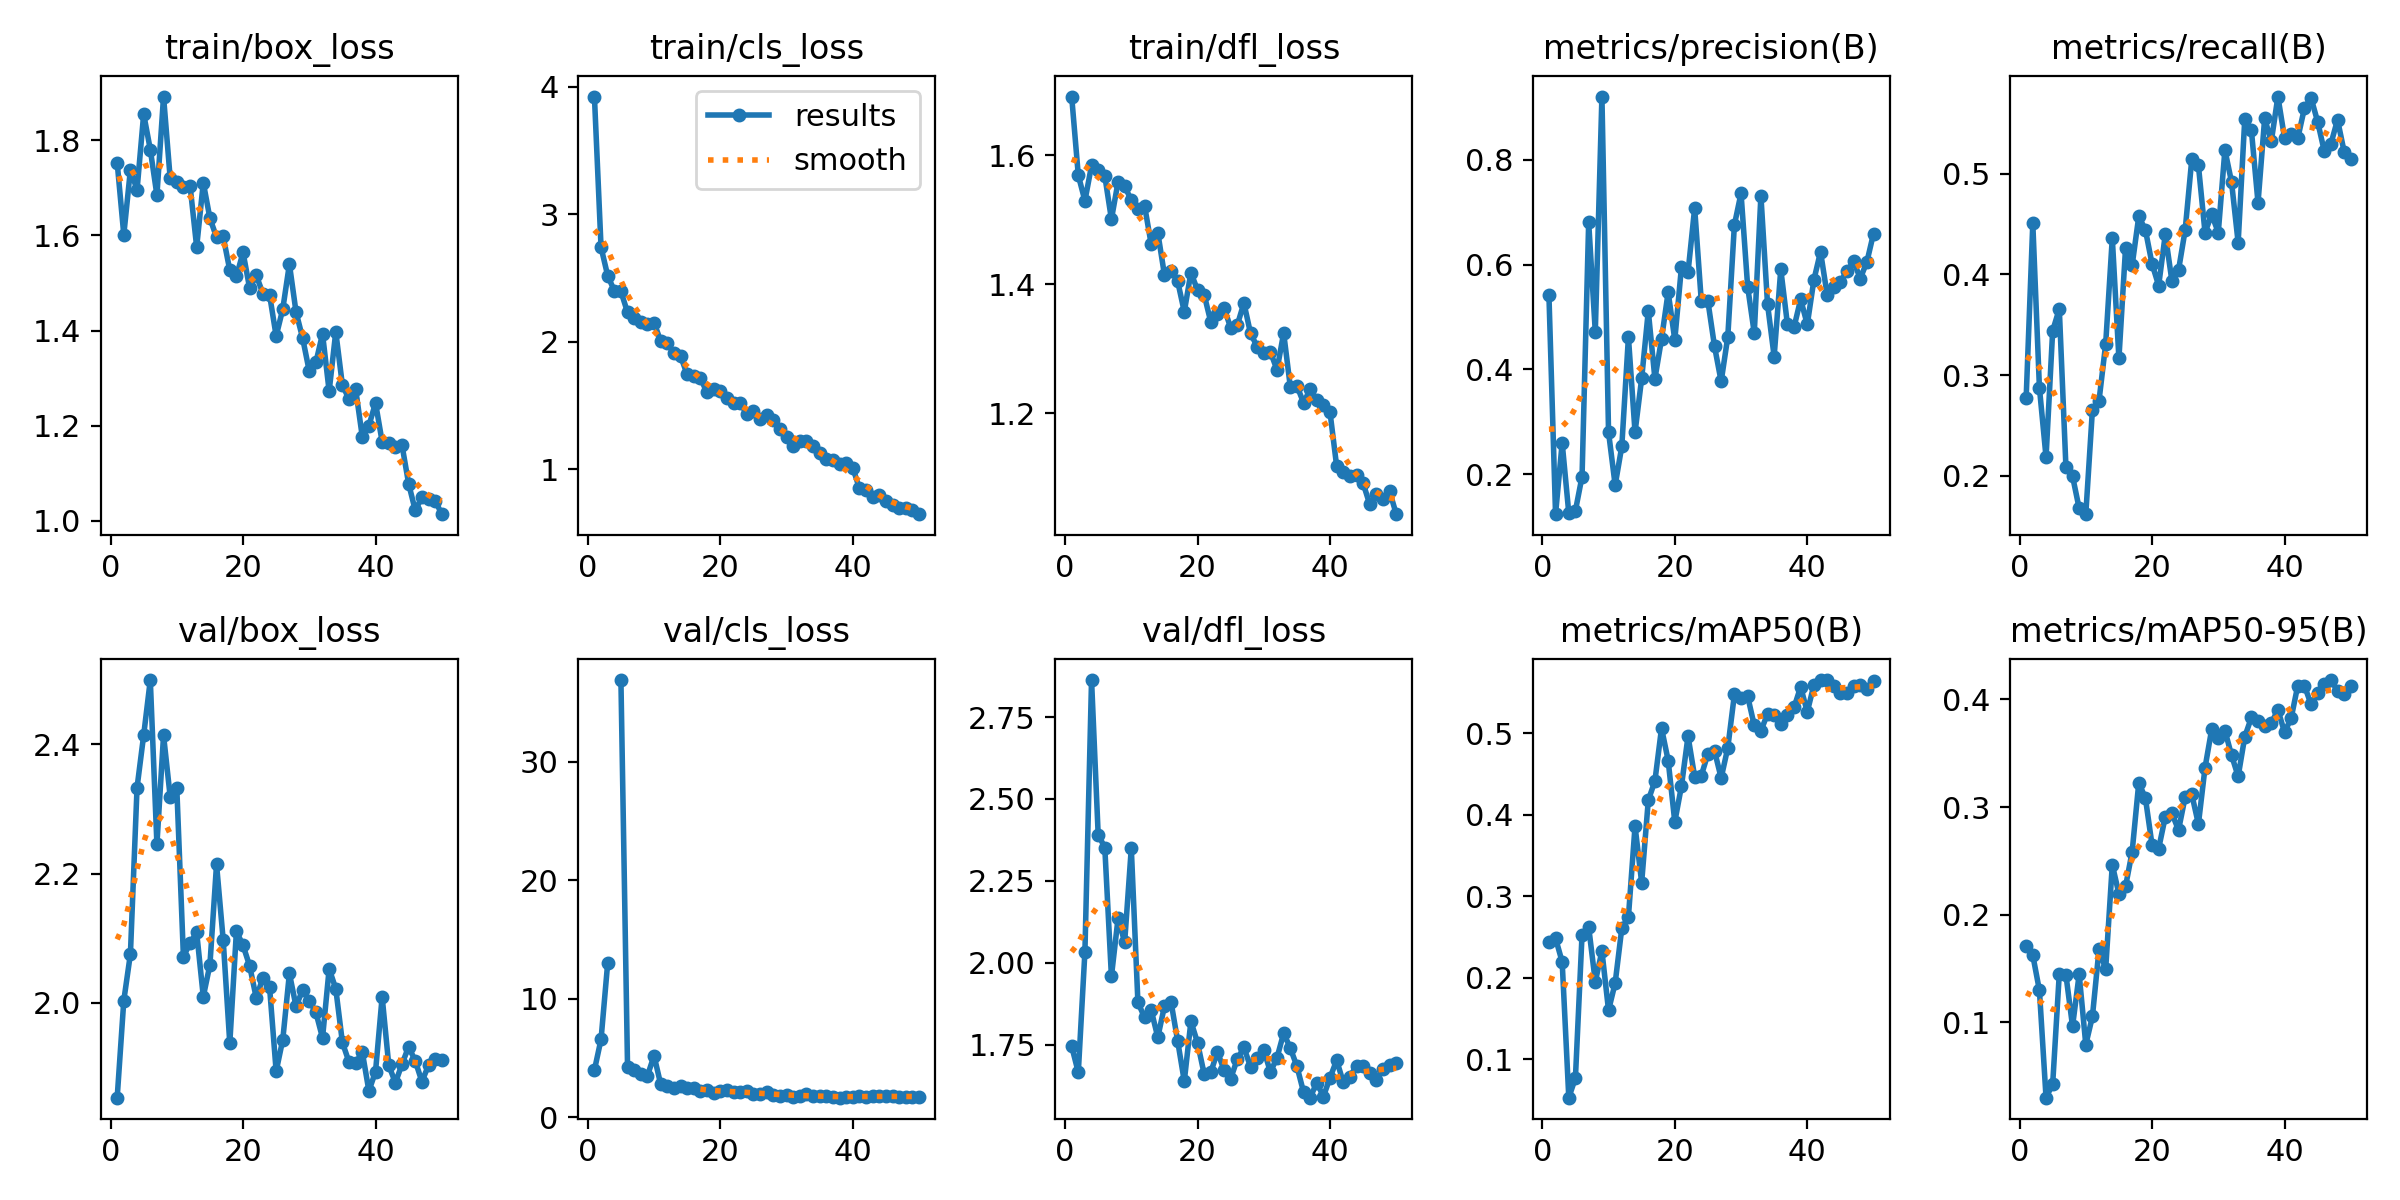

In [13]:
from IPython.display import Image
image_path = '/content/drive/MyDrive/00_GradProject/runs/detect/train/results.png'
Image(filename=image_path, width=600)

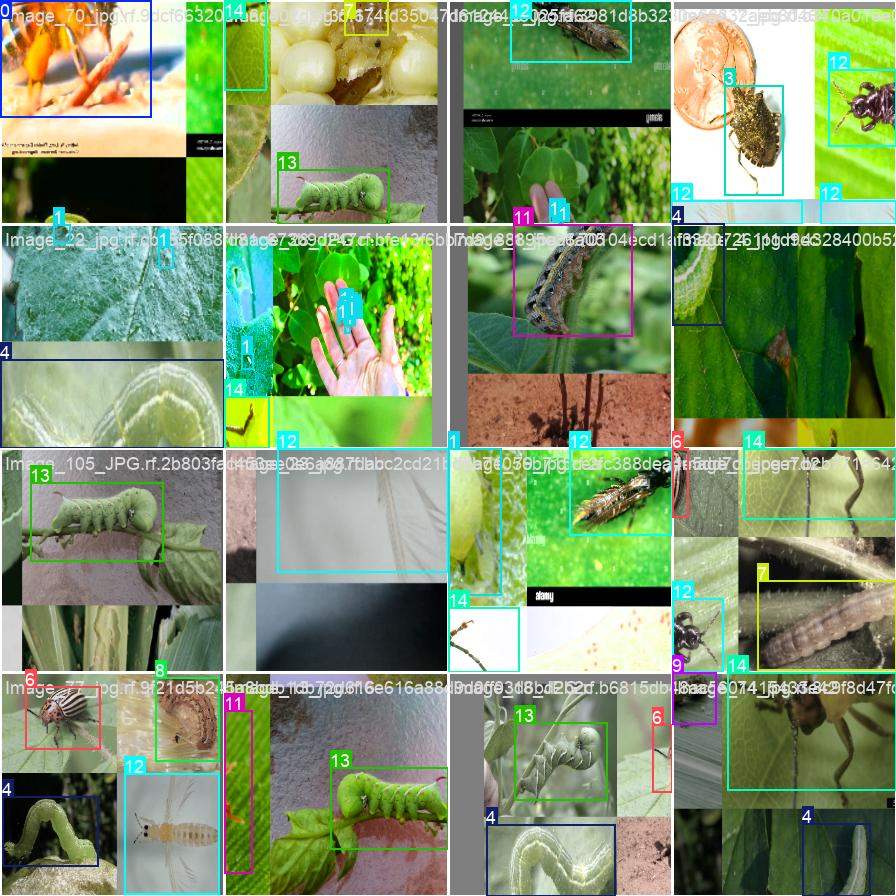

In [14]:
image_path = '/content/drive/MyDrive/00_GradProject/runs/detect/train/train_batch2.jpg'
Image(filename=image_path, width =600)

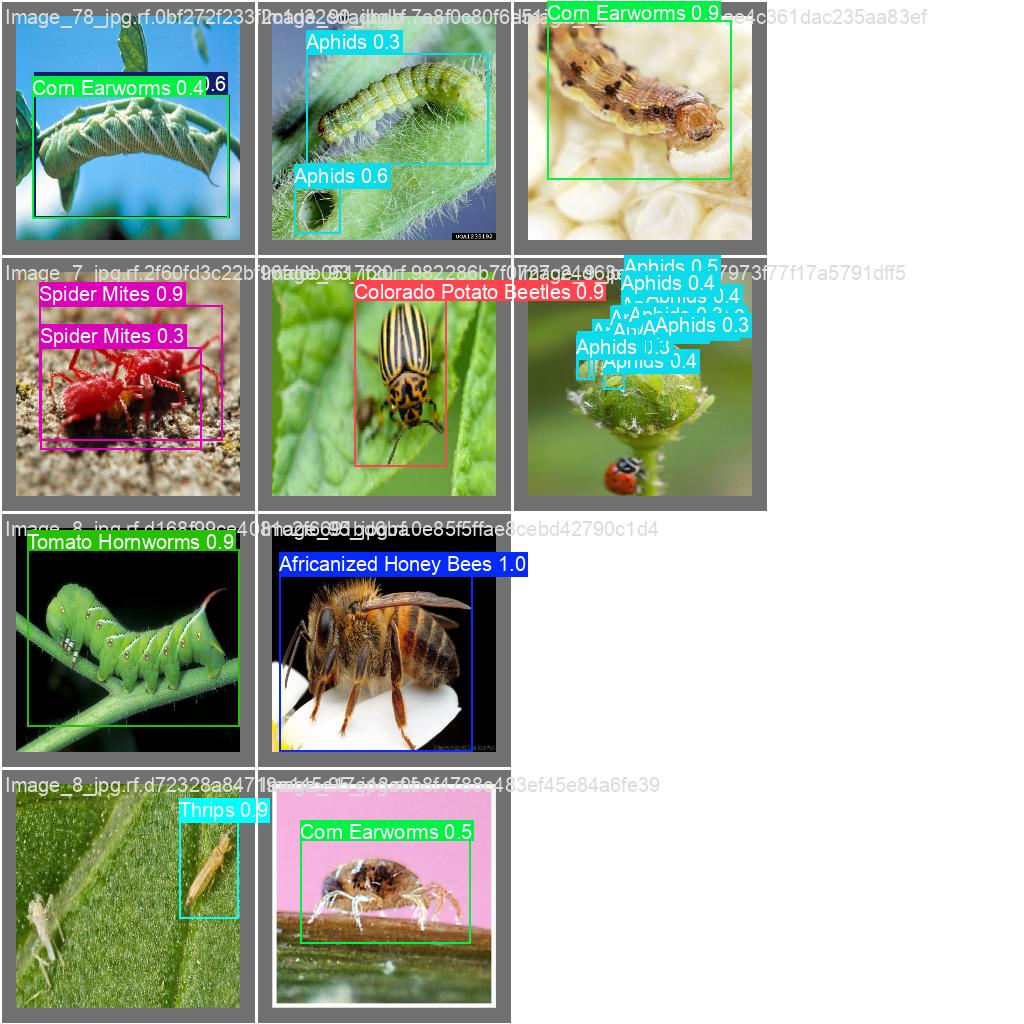

In [15]:
Image(filename='/content/drive/MyDrive/00_GradProject/runs/detect/train/val_batch2_pred.jpg', width=600)

In [16]:
!yolo task=detect mode=val model="/content/drive/MyDrive/00_GradProject/runs/detect/train/weights/best.pt" data=/content/drive/MyDrive/00_GradProject/data.yaml

Ultralytics 8.4.8 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 113 layers, 43,618,173 parameters, 0 gradients, 164.9 GFLOPs
val: Fast image access ✅ (ping: 0.4±0.2 ms, read: 23.3±10.5 MB/s, size: 41.1 KB)
val: Scanning /content/drive/MyDrive/00_GradProject/valid/labels.cache... 74 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 74/74 14.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 2.7it/s 1.8s
                   all         74        305      0.608       0.53      0.559      0.418
Africanized Honey Bees          4          4      0.559      0.649      0.647      0.617
                Aphids          6         92      0.511     0.0652      0.123     0.0277
             Armyworms          4          7       0.28      0.143      0.128      0.057
Brown Marmorated Stink Bugs          4          4      0.694          1      0.995      0.753
       Cabbage Loopers       

## **Inference on Test images**

In [17]:
!yolo task=detect mode=predict model="/content/drive/MyDrive/00_GradProject/runs/detect/train/weights/best.pt" conf=0.25 source="/content/drive/MyDrive/00_GradProject/test/images" save=True


Ultralytics 8.4.8 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 113 layers, 43,618,173 parameters, 0 gradients, 164.9 GFLOPs

image 1/45 /content/drive/MyDrive/00_GradProject/test/images/Image_100_jpg.rf.aabe017f8d0cb9a11c5743718f035298.jpg: 224x224 1 Brown Marmorated Stink Bugs, 19.3ms
image 2/45 /content/drive/MyDrive/00_GradProject/test/images/Image_10_jpg.rf.316fb2cd444577843c5a1e61bc200bb2.jpg: 224x224 1 Fall armyworm, 18.7ms
image 3/45 /content/drive/MyDrive/00_GradProject/test/images/Image_11_jpg.rf.31921a296e1eb77ffe0830a003692cda.jpg: 224x224 1 Citrus-Canker, 1 Colorado Potato Beetles, 19.1ms
image 4/45 /content/drive/MyDrive/00_GradProject/test/images/Image_12_jpg.rf.05451dc1ab002d09495df94a9c971b00.jpg: 224x224 1 Corn Earworms, 1 Fall armyworm, 18.7ms
image 5/45 /content/drive/MyDrive/00_GradProject/test/images/Image_13_jpg.rf.9c490175c9c1cb3e5e23a892af37ff23.jpg: 224x224 28 Citrus-Cankers, 18.7ms
image 6/45 /content/drive/MyDrive/00_G

In [18]:
# !cp -r /content/runs/detect/predict /content/drive/MyDrive/ObjectdetectionData/test_results


In [19]:
import glob
from IPython.display import Image, display

for image_path in glob.glob('runs/detect/predict/*.jpg')[:20]:
      display(Image(filename=image_path, width=600))
      print("\n")

Output hidden; open in https://colab.research.google.com to view.